# Testando um modelo simples de aprendizado de um Datase aleatório

## Imports

In [1]:
import IPython.display as ipd
import json
import numpy as np
import matplotlib.pyplot as plt
import random
import soundfile as sf
import pandas as pd

from fm_synth import FMSynth, SAMPLE_RATE


## Gerando um dataset aleatório

### Rodando aleatoriamente e salvando o resultado

In [2]:
duracao_amostras = 4
tamanho_dataset = 1000
precisao_decimal = 3

In [3]:
# with open("dataset/parameters.json", "w") as f:
#     f.write("[\n")
#     for i in range(tamanho_dataset):
#         # Sorteando uma frequencia báse, na faixa audível humana
#         frequencia_base = random.random() * 20000 + 20
#         frequencia_base = round(frequencia_base, precisao_decimal)

#         # Sorteando os demais parâmetros da síntese
#         amplitude1 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency1 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta2 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude2 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency2 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta3 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude3 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency3 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta4 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude4 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency4 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta5 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude5 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         frequency5 = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         beta_carrier = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         amplitude_carrier = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         attack = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         decay = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         sustain = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         release = round((random.random() * 0.999 + 0.001), precisao_decimal)
#         if decay <= 0:
#             print(decay)

#         # Guardando os parâmetros em JSON
#         data = {
#             "id": i,
#             "frequencia_base": frequencia_base,
#             "amplitude1": amplitude1,
#             "frequency1": frequency1,
#             "beta2": beta2,
#             "amplitude2": amplitude2,
#             "frequency2": frequency2,
#             "beta3": beta3,
#             "amplitude3": amplitude3,
#             "frequency3": frequency3,
#             "beta4": beta4,
#             "amplitude4": amplitude4,
#             "frequency4": frequency4,
#             "beta5": beta5,
#             "amplitude5": amplitude5,
#             "frequency5": frequency5,
#             "beta_carrier": beta_carrier,
#             "amplitude_carrier": amplitude_carrier,
#             "attack": attack,
#             "decay": decay,
#             "sustain": sustain,
#             "release": release,
#         }

#         # Codificando os parâmetros em json
#         data = json.dumps(data)

#         # Imprimindo na saída
#         f.write(data)
#         if (i<tamanho_dataset-1):
#             f.write(",\n")
#         else:
#             f.write("\n")

#         # Sintetizando o sinal
#         fm_synth = FMSynth(
#             amplitude1=amplitude1,
#             frequency1=frequency1,
#             beta2=beta2,
#             amplitude2=amplitude2,
#             frequency2=frequency2,
#             beta3=beta3,
#             amplitude3=amplitude3,
#             frequency3=frequency3,
#             beta4=beta4,
#             amplitude4=amplitude4,
#             frequency4=frequency4,
#             beta5=beta5,
#             amplitude5=amplitude5,
#             frequency5=frequency5,
#             beta_carrier=beta_carrier,
#             amplitude_carrier=amplitude_carrier,
#             attack=attack,
#             decay=decay,
#             sustain=sustain,
#             release=release,
#         )
#         signal = fm_synth.synth_alg1(duracao_amostras, frequencia_base)
        
#         # Escrevendo o áudio em arquivo
#         sf.write(f"dataset/sample_{i}.wav", signal, SAMPLE_RATE)

#     f.write("]")

## Lendo o dataset no formato pandas

### Lendo as variáveis de entrada

In [4]:
samples = []
for i in range(tamanho_dataset):
    signal = sf.read(f"dataset/sample_{i}.wav")
    samples.append(signal)

samples = pd.DataFrame(samples)

In [5]:
samples = samples.drop(columns=[1])
samples.head()

,0
0,"[0.0, -6.103515625e-05, 6.103515625e-05, 3.051..."
1,"[0.0, -3.0517578125e-05, -3.0517578125e-05, 0...."
2,"[0.0, -6.103515625e-05, 9.1552734375e-05, 0.00..."
3,"[0.0, 0.0, 3.0517578125e-05, 9.1552734375e-05,..."
4,"[0.0, 0.0, 0.0, 0.0, -3.0517578125e-05, -3.051..."


### Lendo o alvo

In [6]:
with open("dataset/parameters.json", "r") as f:
    target = f.read()

target = json.loads(target)
target = target[:tamanho_dataset]

target = pd.DataFrame(target)
target.head()

,id,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,0,15061.183,0.524,0.477,0.344,0.765,0.549,0.811,0.439,0.183,...,0.787,0.739,0.120,0.204,0.147,0.312,0.287,0.127,0.726,0.848
1,1,16951.022,0.082,0.350,0.035,0.879,0.471,0.787,0.275,0.393,...,0.697,0.788,0.960,0.593,0.192,0.038,0.701,0.450,0.404,0.560
2,2,15429.197,0.736,0.356,0.461,0.279,0.581,0.204,0.291,0.803,...,0.058,0.346,0.573,0.535,0.972,0.612,0.492,0.038,0.472,0.142
3,3,1051.543,0.898,0.537,0.633,0.708,0.926,0.369,0.107,0.342,...,0.800,0.849,0.108,0.993,0.133,0.337,0.362,0.150,0.629,0.580
4,4,2842.837,0.879,0.063,0.835,0.561,0.806,0.412,0.605,0.589,...,0.528,0.018,0.923,0.378,0.290,0.092,0.882,0.899,0.674,0.224


In [7]:
target = target.drop(columns=["id"])
target.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,15061.183,0.524,0.477,0.344,0.765,0.549,0.811,0.439,0.183,0.289,...,0.787,0.739,0.120,0.204,0.147,0.312,0.287,0.127,0.726,0.848
1,16951.022,0.082,0.350,0.035,0.879,0.471,0.787,0.275,0.393,0.079,...,0.697,0.788,0.960,0.593,0.192,0.038,0.701,0.450,0.404,0.560
2,15429.197,0.736,0.356,0.461,0.279,0.581,0.204,0.291,0.803,0.414,...,0.058,0.346,0.573,0.535,0.972,0.612,0.492,0.038,0.472,0.142
3,1051.543,0.898,0.537,0.633,0.708,0.926,0.369,0.107,0.342,0.733,...,0.800,0.849,0.108,0.993,0.133,0.337,0.362,0.150,0.629,0.580
4,2842.837,0.879,0.063,0.835,0.561,0.806,0.412,0.605,0.589,0.155,...,0.528,0.018,0.923,0.378,0.290,0.092,0.882,0.899,0.674,0.224


### Juntando alvo e features

In [8]:
ds = pd.concat([samples, target], axis=1)
ds.head()

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
0,"[0.0, -6.103515625e-05, 6.103515625e-05, 3.051...",15061.183,0.524,0.477,0.344,0.765,0.549,0.811,0.439,0.183,...,0.787,0.739,0.120,0.204,0.147,0.312,0.287,0.127,0.726,0.848
1,"[0.0, -3.0517578125e-05, -3.0517578125e-05, 0....",16951.022,0.082,0.350,0.035,0.879,0.471,0.787,0.275,0.393,...,0.697,0.788,0.960,0.593,0.192,0.038,0.701,0.450,0.404,0.560
2,"[0.0, -6.103515625e-05, 9.1552734375e-05, 0.00...",15429.197,0.736,0.356,0.461,0.279,0.581,0.204,0.291,0.803,...,0.058,0.346,0.573,0.535,0.972,0.612,0.492,0.038,0.472,0.142
3,"[0.0, 0.0, 3.0517578125e-05, 9.1552734375e-05,...",1051.543,0.898,0.537,0.633,0.708,0.926,0.369,0.107,0.342,...,0.800,0.849,0.108,0.993,0.133,0.337,0.362,0.150,0.629,0.580
4,"[0.0, 0.0, 0.0, 0.0, -3.0517578125e-05, -3.051...",2842.837,0.879,0.063,0.835,0.561,0.806,0.412,0.605,0.589,...,0.528,0.018,0.923,0.378,0.290,0.092,0.882,0.899,0.674,0.224


In [9]:
ds.shape

(1000, 22)

## Separando treino e teste

In [10]:
train = ds.sample(frac=0.75, random_state=0)
test = ds.drop(train.index)

In [11]:
train.head(5)

,0,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
993,"[0.0, 3.0517578125e-05, -0.00018310546875, 0.0...",8817.278,0.978,0.489,0.501,0.007,0.126,0.196,0.862,0.461,...,0.381,0.931,0.071,0.235,0.166,0.853,0.441,0.810,0.005,0.430
859,"[0.0, -3.0517578125e-05, -9.1552734375e-05, -6...",19392.466,0.514,0.720,0.865,0.681,0.650,0.282,0.877,0.992,...,0.565,0.330,0.973,0.234,0.708,0.891,0.996,0.504,0.526,0.840
298,"[0.0, 3.0517578125e-05, 6.103515625e-05, -0.00...",4415.950,0.867,0.971,0.216,0.636,0.788,0.085,0.890,0.498,...,0.911,0.921,0.125,0.463,0.464,0.766,0.578,0.664,0.177,0.634
553,"[0.0, 6.103515625e-05, -3.0517578125e-05, -0.0...",5680.907,0.125,0.696,0.770,0.044,0.480,0.299,0.797,0.708,...,0.084,0.451,0.871,0.987,0.038,0.886,0.508,0.090,0.869,0.467
672,"[0.0, 3.0517578125e-05, -0.0001220703125, 9.15...",8129.444,0.047,0.667,0.831,0.748,0.640,0.172,0.429,0.501,...,0.893,0.343,0.940,0.310,0.110,0.298,0.250,0.279,0.257,0.068


In [12]:
x = pd.DataFrame(train[0])
x.head()

,0
993,"[0.0, 3.0517578125e-05, -0.00018310546875, 0.0..."
859,"[0.0, -3.0517578125e-05, -9.1552734375e-05, -6..."
298,"[0.0, 3.0517578125e-05, 6.103515625e-05, -0.00..."
553,"[0.0, 6.103515625e-05, -3.0517578125e-05, -0.0..."
672,"[0.0, 3.0517578125e-05, -0.0001220703125, 9.15..."


In [13]:
x = np.array(x[0].values.tolist())
x[0]

array([ 0.00000000e+00,  3.05175781e-05, -1.83105469e-04, ...,
       -3.05175781e-05,  0.00000000e+00, -3.05175781e-05])

In [14]:
len(x[0])

88200

In [15]:
y = train.drop(columns=[0])
y.head()

,frequencia_base,amplitude1,frequency1,beta2,amplitude2,frequency2,beta3,amplitude3,frequency3,beta4,...,frequency4,beta5,amplitude5,frequency5,beta_carrier,amplitude_carrier,attack,decay,sustain,release
993,8817.278,0.978,0.489,0.501,0.007,0.126,0.196,0.862,0.461,0.633,...,0.381,0.931,0.071,0.235,0.166,0.853,0.441,0.810,0.005,0.430
859,19392.466,0.514,0.720,0.865,0.681,0.650,0.282,0.877,0.992,0.890,...,0.565,0.330,0.973,0.234,0.708,0.891,0.996,0.504,0.526,0.840
298,4415.950,0.867,0.971,0.216,0.636,0.788,0.085,0.890,0.498,0.188,...,0.911,0.921,0.125,0.463,0.464,0.766,0.578,0.664,0.177,0.634
553,5680.907,0.125,0.696,0.770,0.044,0.480,0.299,0.797,0.708,0.627,...,0.084,0.451,0.871,0.987,0.038,0.886,0.508,0.090,0.869,0.467
672,8129.444,0.047,0.667,0.831,0.748,0.640,0.172,0.429,0.501,0.348,...,0.893,0.343,0.940,0.310,0.110,0.298,0.250,0.279,0.257,0.068


### Quebrando a entrada em frames

In [16]:
frame_length = 2048

dataset = []
for sample in x:
  length = sample.shape[0]
  num_frames = int(length / frame_length)
  amostras_uteis = num_frames * frame_length
  sample_cutted = sample[:amostras_uteis]
  sample_cutted = sample_cutted.reshape(num_frames, frame_length)
  dataset.append(sample_cutted)

x = np.array(dataset)
print(x.shape)
x[0:5]

(750, 43, 2048)


array([[[ 0.00000000e+00,  3.05175781e-05, -1.83105469e-04, ...,
         -1.79412842e-01,  1.44714355e-01, -5.41992188e-02],
        [-5.79528809e-02,  1.47705078e-01, -1.79779053e-01, ...,
         -3.36639404e-01,  1.97692871e-01,  1.64184570e-02],
        [-2.23175049e-01,  3.45520020e-01, -3.38409424e-01, ...,
         -4.20898438e-01,  1.45080566e-01,  1.87164307e-01],
        ...,
        [-1.83105469e-03,  2.71606445e-03, -2.62451172e-03, ...,
         -1.46484375e-03,  4.27246094e-04,  7.32421875e-04],
        [-1.64794922e-03,  1.89208984e-03, -1.43432617e-03, ...,
         -4.88281250e-04, -1.52587891e-04,  6.40869141e-04],
        [-9.76562500e-04,  8.85009766e-04, -5.18798828e-04, ...,
         -3.05175781e-05, -3.05175781e-05,  3.05175781e-05]],

       [[ 0.00000000e+00, -3.05175781e-05, -9.15527344e-05, ...,
          2.22167969e-02,  3.25012207e-02,  5.02929688e-02],
        [ 7.74536133e-02, -2.73437500e-02, -6.90612793e-02, ...,
         -1.57043457e-01, -3.83911133e

## Construindo o modelo

In [17]:
from keras.layers import TimeDistributed, Dense, Input, Lambda, BatchNormalization, Concatenate, Conv1D, ZeroPadding1D
from keras.models import Model
from tensorflow.keras.utils import plot_model
from keras.callbacks import EarlyStopping
import tensorflow as tf

2024-10-28 01:26:11.282387: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-28 01:26:11.304947: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-10-28 01:26:11.328133: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-10-28 01:26:11.335627: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-10-28 01:26:11.352510: I tensorflow/core/platform/cpu_feature_guar

In [18]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  0


I0000 00:00:1730089573.778144    9193 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-10-28 01:26:13.820942: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2343] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


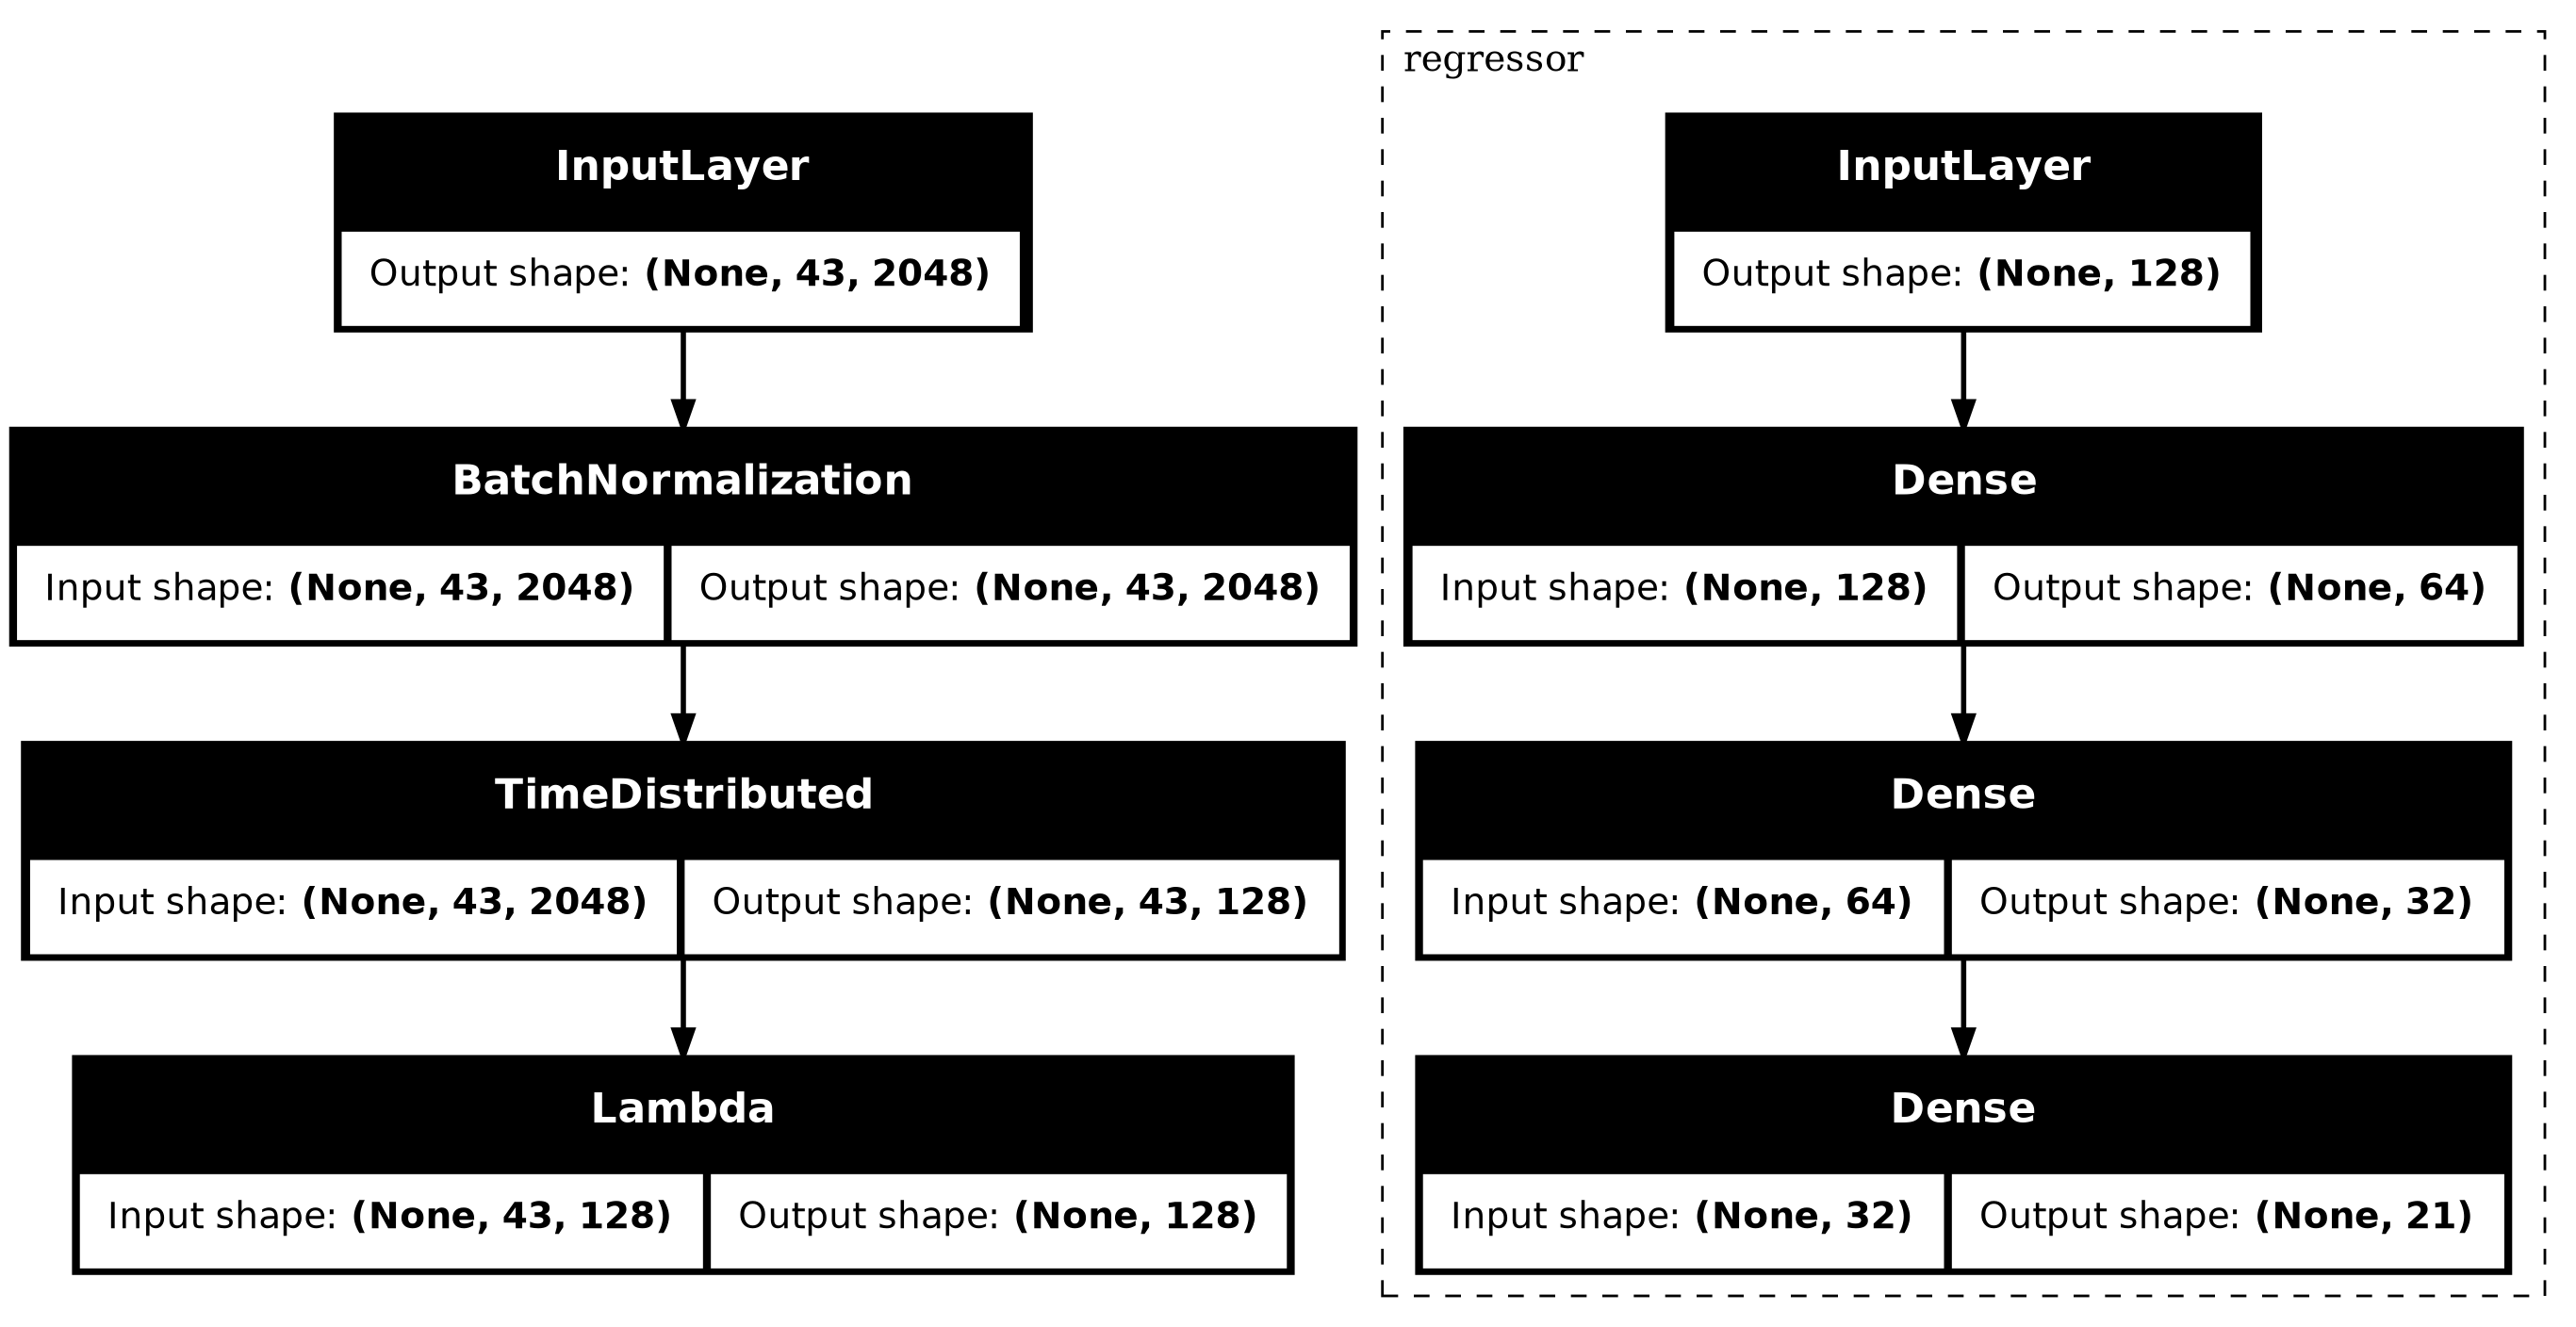

In [19]:
def extrator_features(input_dims, activation, bias):
  input_layer = Input(shape=[input_dims])

  x_0 = Dense(int(input_dims), activation=activation, use_bias=bias, kernel_regularizer="l2")(input_layer)
  x_2 = Dense(int(input_dims/4), activation=activation, use_bias=bias)(x_0)
  x_3 = Dense(int(input_dims/8), activation=activation, use_bias=bias)(x_2)
  # x_4 = tf.keras.layers.Dropout(0.3)(x_3)
  x_bottleneck = Dense(int(input_dims/16), activation=activation, name='encoder', use_bias=True)(x_3)

  return Model(input_layer, x_bottleneck, name="features")

def regressor(input_dims, output_dims, activation, bias):
  input_layer = Input(shape=[input_dims])

  x_0 = Dense(int(input_dims/2), activation=activation, use_bias=bias)(input_layer)
  x_2 = Dense(int(input_dims/4), activation=activation, use_bias=bias)(x_0)
  saidas = Dense(output_dims, activation=activation, name='regressor_saidas', use_bias=True)(x_2)

  return Model(input_layer, saidas, name="regressor")

def my_mean(x):
  return tf.reduce_mean(x, axis=1)

def build_models(input_len, input_dims, output_dims, activation, bias):
  # Camadas de entrada
  input_layer = Input(shape=(input_len, input_dims))

  x_n = BatchNormalization()(input_layer)

  # Kernels
  extrator = extrator_features(input_dims, activation, bias)

  # Features
  features = TimeDistributed(extrator, name="features_padrao")(x_n)

  # Juntando as features
  media_features = Lambda(my_mean)(features)

  # Regrssão
  regressao = regressor(media_features.shape[1], output_dims, activation, bias)

  saida = regressao(media_features)
  
  return (
      Model(input_layer, saida, name="regressao"),
      Model(input_layer, media_features, name="projecao")
  )

model, features = build_models(x.shape[1], x.shape[2], y.shape[1], 'elu', False)
model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse', 'mean_absolute_percentage_error'])
plot_model(model, show_shapes=True, expand_nested=True)

In [20]:
# Callback para recuperar o melhor peso, e parar quando ficar três épocas sem melhora
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3, restore_best_weights=True)

# Treinando o modelo
history = model.fit(x, y, epochs=10, validation_split = 0.2, callbacks=[callback])

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 572ms/step - loss: 6175325.5000 - mae: 479.1341 - mean_absolute_percentage_error: 4099.2207 - mse: 6175304.5000 - val_loss: 5858464.5000 - val_mae: 498.3316 - val_mean_absolute_percentage_error: 26626.4766 - val_mse: 5858440.5000
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 506ms/step - loss: 3632866.2500 - mae: 551.3824 - mean_absolute_percentage_error: 165786.2969 - mse: 3632841.2500 - val_loss: 2782816.2500 - val_mae: 403.2231 - val_mean_absolute_percentage_error: 77492.3984 - val_mse: 2782789.7500
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 504ms/step - loss: 1783377.5000 - mae: 359.8827 - mean_absolute_percentage_error: 123581.4141 - mse: 1783350.7500 - val_loss: 1547036.0000 - val_mae: 241.4402 - val_mean_absolute_percentage_error: 5133.1489 - val_mse: 1547008.3750
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 502ms/step - loss: 1413625.7500 - mae: 222.9653 - mean_absolute_percentage_error: 4141.7012 - mse: 1413598.1250 - val_loss: 1636465.8750 - 

In [21]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mae,mean_absolute_percentage_error,mse,val_loss,val_mae,val_mean_absolute_percentage_error,val_mse,epoch
5,1285390.000,205.169922,804.488831,1285361.625,1760137.000,242.804993,653.815247,1760108.375,5
6,1205492.375,200.339172,807.177490,1205463.625,1496773.500,230.760101,655.778564,1496744.250,6
7,1224796.500,200.559158,834.474365,1224767.125,1625955.125,235.477997,654.331787,1625925.500,7
8,1105425.875,188.480453,953.917786,1105396.375,1584537.750,233.152161,654.544617,1584507.750,8
9,1064534.000,183.541321,966.265503,1064504.000,1793412.500,242.466721,653.606934,1793382.375,9


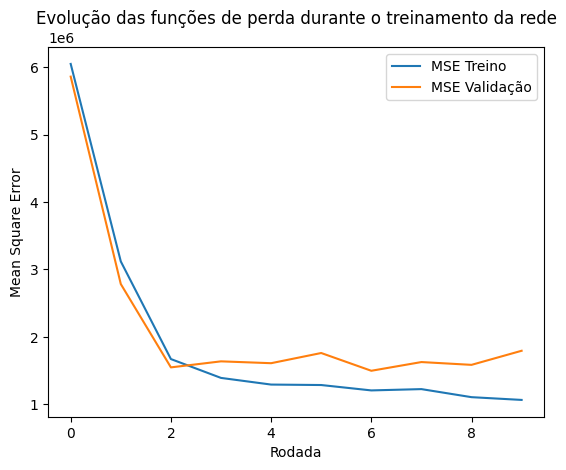

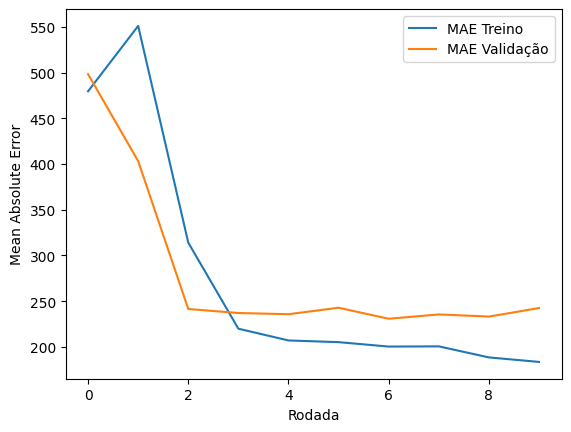

In [22]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch

plt.figure()
plt.title("Evolução das funções de perda durante o treinamento da rede")
plt.xlabel('Rodada')
plt.ylabel('Mean Square Error')
plt.plot(hist['epoch'], hist['mse'], label='MSE Treino')
plt.plot(hist['epoch'], hist['val_mse'], label = 'MSE Validação')
plt.legend()

plt.figure()
plt.xlabel('Rodada')
plt.ylabel('Mean Absolute Error')
plt.plot(hist['epoch'], hist['mae'], label='MAE Treino')
plt.plot(hist['epoch'], hist['val_mae'], label = 'MAE Validação')
plt.legend()

plt.show()